# Bluestock MF Analytics — Day 4: Fund Performance Analytics

Computes daily returns, CAGR, Sharpe, Sortino, Alpha/Beta vs Nifty 100,
Maximum Drawdown, a composite Fund Scorecard, and a benchmark comparison
chart — all derived directly from NAV history and benchmark index data,
independent of the pre-supplied `07_scheme_performance.csv`, so the numbers
here are a genuine from-scratch computation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path

sns.set_theme(style="whitegrid")
CHART_DIR = Path("../reports/charts")
CHART_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR = Path("..")

RF_ANNUAL = 0.065          # RBI repo rate proxy, per project spec
TRADING_DAYS = 252

nav = pd.read_csv("../data/processed/clean_nav.csv", parse_dates=["date"], dtype={"amfi_code": str})
fund_master = pd.read_csv("../data/raw/01_fund_master.csv", dtype={"amfi_code": str})
bench = pd.read_csv("../data/raw/10_benchmark_indices.csv", parse_dates=["date"])
perf_ref = pd.read_csv("../data/processed/clean_performance.csv", dtype={"amfi_code": str})  # for aum_crore, expense ratio

nav = nav.sort_values(["amfi_code", "date"]).reset_index(drop=True)
as_of = nav["date"].max()
print(f"NAV data: {nav['date'].min().date()} to {as_of.date()}  ({nav['amfi_code'].nunique()} funds)")
print(f"Benchmark data: {bench['date'].min().date()} to {bench['date'].max().date()}")


NAV data: 2022-01-03 to 2026-05-29  (40 funds)
Benchmark data: 2022-01-03 to 2026-05-29


## Task 1 — Daily Returns
`daily_return = NAV_t / NAV_t-1 − 1`, computed per fund. Validated by
plotting the pooled distribution and flagging any single-day move beyond
±20%, which would suggest a data error rather than genuine volatility.

Rows with |daily_return| > 20%: 0


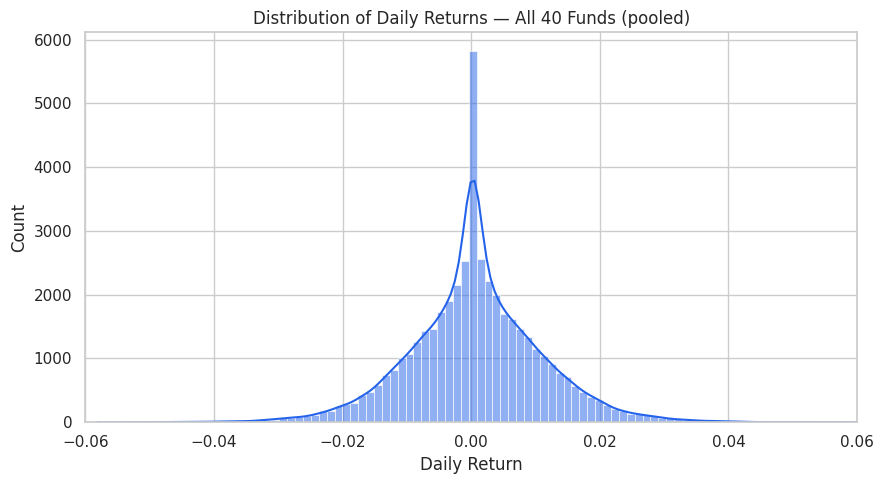

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64


In [2]:
nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

extreme = nav[nav["daily_return"].abs() > 0.20]
print(f"Rows with |daily_return| > 20%: {len(extreme)}")
if len(extreme):
    print(extreme[["amfi_code", "date", "nav", "daily_return"]].head(10))

fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(nav["daily_return"].dropna(), bins=100, kde=True, ax=ax, color="#2563eb")
ax.set_title("Distribution of Daily Returns — All 40 Funds (pooled)")
ax.set_xlabel("Daily Return")
ax.set_xlim(-0.06, 0.06)
plt.tight_layout()
fig.savefig(CHART_DIR / "13_daily_return_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print(nav["daily_return"].describe())


**Validation check:** daily mutual fund returns should cluster tightly
around 0 with a standard deviation well under 5% for equity funds and
under 1% for liquid/debt funds — a fat left or right tail beyond ±20% in a
single day would indicate a NAV data error (e.g. a stock split or bad
scrape), not real fund performance. See the printed count above.

## Task 2 — CAGR (1yr, 3yr, 5yr)
`CAGR = (NAV_end / NAV_start) ^ (1/n_years) − 1`, computed per fund as of
the latest available NAV date.

**Data limitation, stated up front:** NAV history in this dataset starts
2022-01-03. A true 5-year CAGR as of {as_of} would need data back to
~2021, which we don't have — so 5yr CAGR is reported as `NaN` rather than
silently computed off a shorter, misleadingly-labelled window.

In [3]:
def cagr_for_horizon(g, years, as_of):
    start_target = as_of - pd.DateOffset(years=years)
    if g["date"].min() > start_target:
        return np.nan  # not enough history for a true N-year CAGR
    start_row = g[g["date"] <= start_target].iloc[-1]
    end_row = g[g["date"] == as_of]
    if end_row.empty:
        end_row = g.iloc[[-1]]
    n_years = (end_row["date"].iloc[0] - start_row["date"]).days / 365.25
    return (end_row["nav"].iloc[0] / start_row["nav"]) ** (1 / n_years) - 1

cagr_rows = []
for code_, g in nav.groupby("amfi_code"):
    g = g.dropna(subset=["nav"]).sort_values("date")
    cagr_rows.append({
        "amfi_code": code_,
        "cagr_1yr": cagr_for_horizon(g, 1, as_of),
        "cagr_3yr": cagr_for_horizon(g, 3, as_of),
        "cagr_5yr": cagr_for_horizon(g, 5, as_of),
    })
cagr_df = pd.DataFrame(cagr_rows)
cagr_df = cagr_df.merge(fund_master[["amfi_code", "scheme_name", "category"]], on="amfi_code")

n_missing_5yr = cagr_df["cagr_5yr"].isna().sum()
print(f"Funds with insufficient history for 5yr CAGR: {n_missing_5yr} / {len(cagr_df)}")

cagr_df[["scheme_name", "category", "cagr_1yr", "cagr_3yr", "cagr_5yr"]] \
    .sort_values("cagr_3yr", ascending=False) \
    .style.format({"cagr_1yr": "{:.2%}", "cagr_3yr": "{:.2%}", "cagr_5yr": "{:.2%}"})


Funds with insufficient history for 5yr CAGR: 40 / 40


,scheme_name,category,cagr_1yr,cagr_3yr,cagr_5yr
16,Axis Midcap Fund - Regular - Growth,Equity,22.28%,35.10%,nan%
34,Mirae Asset Large Cap Fund - Regular - Growth,Equity,20.38%,33.99%,nan%
24,ICICI Pru Bluechip Fund - Direct - Growth,Equity,13.07%,32.48%,nan%
2,HDFC Mid-Cap Opportunities Fund - Regular - Growth,Equity,53.28%,32.43%,nan%
25,ICICI Pru Midcap Fund - Regular - Growth,Equity,29.63%,31.77%,nan%
19,SBI Bluechip Fund - Regular Plan - Growth,Equity,60.49%,30.45%,nan%
30,Kotak Flexicap Fund - Regular - Growth,Equity,26.68%,29.58%,nan%
36,Mirae Asset Tax Saver Fund - Regular - Growth,Equity,39.78%,29.17%,nan%
3,ABSL Frontline Equity Fund - Regular - Growth,Equity,47.96%,28.96%,nan%
39,DSP Small Cap Fund - Regular - Growth,Equity,65.20%,26.99%,nan%


## Task 3 — Sharpe Ratio
`Sharpe = (Rp − Rf) / Std(Rp) × √252`, using daily returns and Rf = 6.5%
(annual, converted to a daily figure for the excess-return calc).

In [4]:
rf_daily = RF_ANNUAL / TRADING_DAYS

sharpe_rows = []
for code_, g in nav.groupby("amfi_code"):
    r = g["daily_return"].dropna()
    if len(r) < 30:
        continue
    excess = r - rf_daily
    sharpe = excess.mean() / r.std() * np.sqrt(TRADING_DAYS)
    sharpe_rows.append({"amfi_code": code_, "sharpe_ratio": sharpe})
sharpe_df = pd.DataFrame(sharpe_rows)
sharpe_df = sharpe_df.merge(fund_master[["amfi_code", "scheme_name", "category"]], on="amfi_code")
sharpe_df = sharpe_df.sort_values("sharpe_ratio", ascending=False).reset_index(drop=True)
sharpe_df["rank"] = sharpe_df.index + 1

print("Top 10 funds by Sharpe ratio:")
sharpe_df.head(10)[["rank", "scheme_name", "category", "sharpe_ratio"]]


Top 10 funds by Sharpe ratio:


,rank,scheme_name,category,sharpe_ratio
0,1,Mirae Asset Large Cap Fund - Regular - Growth,Equity,1.448291
1,2,Kotak Flexicap Fund - Regular - Growth,Equity,1.306744
2,3,Mirae Asset Tax Saver Fund - Regular - Growth,Equity,1.234930
3,4,SBI Bluechip Fund - Regular Plan - Growth,Equity,1.208267
4,5,ICICI Pru Midcap Fund - Regular - Growth,Equity,1.180101
5,6,DSP Midcap Fund - Regular - Growth,Equity,1.132122
6,7,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity,1.093699
7,8,Nippon India Large Cap Fund - Regular - Growth,Equity,1.081659
8,9,ABSL Frontline Equity Fund - Regular - Growth,Equity,1.027213
9,10,ICICI Pru Bluechip Fund - Direct - Growth,Equity,1.026524


## Task 4 — Sortino Ratio
Same as Sharpe, but the denominator uses downside deviation only (standard
deviation of negative-return days).

In [5]:
sortino_rows = []
for code_, g in nav.groupby("amfi_code"):
    r = g["daily_return"].dropna()
    if len(r) < 30:
        continue
    excess = r - rf_daily
    downside = r[r < 0]
    downside_std = downside.std() if len(downside) > 1 else np.nan
    sortino = excess.mean() / downside_std * np.sqrt(TRADING_DAYS) if downside_std else np.nan
    sortino_rows.append({"amfi_code": code_, "sortino_ratio": sortino})
sortino_df = pd.DataFrame(sortino_rows)
sortino_df = sortino_df.merge(fund_master[["amfi_code", "scheme_name"]], on="amfi_code")
sortino_df.sort_values("sortino_ratio", ascending=False).head(10)[["scheme_name", "sortino_ratio"]]


,scheme_name,sortino_ratio
34,Mirae Asset Large Cap Fund - Regular - Growth,2.385644
30,Kotak Flexicap Fund - Regular - Growth,2.364320
36,Mirae Asset Tax Saver Fund - Regular - Growth,2.146914
19,SBI Bluechip Fund - Regular Plan - Growth,2.140267
25,ICICI Pru Midcap Fund - Regular - Growth,2.029353
38,DSP Midcap Fund - Regular - Growth,1.875101
9,Nippon India Large Cap Fund - Regular - Growth,1.850133
2,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,1.829134
24,ICICI Pru Bluechip Fund - Direct - Growth,1.805294
3,ABSL Frontline Equity Fund - Regular - Growth,1.799563


## Task 5 — Alpha & Beta vs Nifty 100
OLS regression of each fund's daily returns on Nifty 100 daily returns via
`scipy.stats.linregress`. `Alpha = intercept × 252`, `Beta = slope`.

In [6]:
nifty100 = bench[bench["index_name"] == "NIFTY100"].sort_values("date").copy()
nifty100["bench_return"] = nifty100["close_value"].pct_change()
nifty100 = nifty100[["date", "bench_return"]].dropna()

alpha_beta_rows = []
for code_, g in nav.groupby("amfi_code"):
    merged = g[["date", "daily_return"]].merge(nifty100, on="date", how="inner").dropna()
    if len(merged) < 60:
        continue
    slope, intercept, r_value, p_value, std_err = stats.linregress(
        merged["bench_return"], merged["daily_return"])
    alpha_beta_rows.append({
        "amfi_code": code_,
        "alpha": intercept * TRADING_DAYS,
        "beta": slope,
        "r_squared": r_value ** 2,
        "p_value": p_value,
        "n_obs": len(merged),
    })

alpha_beta_df = pd.DataFrame(alpha_beta_rows)
alpha_beta_df = alpha_beta_df.merge(fund_master[["amfi_code", "scheme_name", "category"]], on="amfi_code")
alpha_beta_df = alpha_beta_df[["amfi_code", "scheme_name", "category", "alpha", "beta", "r_squared", "p_value", "n_obs"]]
alpha_beta_df = alpha_beta_df.sort_values("alpha", ascending=False)

alpha_beta_df.to_csv(OUT_DIR / "alpha_beta.csv", index=False)
print(f"Saved alpha_beta.csv ({len(alpha_beta_df)} funds)")
print(f"\nR-squared vs Nifty 100 — mean: {alpha_beta_df['r_squared'].mean():.4f}, "
      f"max: {alpha_beta_df['r_squared'].max():.4f}  "
      f"(near-zero across the board — see note below)")
alpha_beta_df.head(10)


Saved alpha_beta.csv (40 funds)

R-squared vs Nifty 100 — mean: 0.0006, max: 0.0028  (near-zero across the board — see note below)


,amfi_code,scheme_name,category,alpha,beta,r_squared,p_value,n_obs
21,119598,SBI Small Cap Fund - Regular Plan - Growth,Equity,0.303370,-0.023196,1.414258e-04,0.687179,1149
39,149324,DSP Small Cap Fund - Regular - Growth,Equity,0.300579,0.011455,3.532991e-05,0.840494,1149
25,120505,ICICI Pru Midcap Fund - Regular - Growth,Equity,0.292636,0.000549,1.345534e-07,0.990090,1149
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,Equity,0.282704,0.018134,1.748889e-04,0.654295,1149
30,120843,Kotak Flexicap Fund - Regular - Growth,Equity,0.273305,-0.022830,3.430543e-04,0.530528,1149
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity,0.271954,0.005104,1.206652e-05,0.906369,1149
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,Equity,0.269838,0.023684,4.625437e-04,0.466427,1149
38,149323,DSP Midcap Fund - Regular - Growth,Equity,0.265986,-0.002523,3.357978e-06,0.950525,1149
16,119094,Axis Midcap Fund - Regular - Growth,Equity,0.260767,-0.066265,1.936879e-03,0.135988,1149
19,119551,SBI Bluechip Fund - Regular Plan - Growth,Equity,0.232010,-0.031751,8.869789e-04,0.313143,1149


**Important finding, not a bug — read before writing your report:**
Across all 40 funds, R² against Nifty 100 is essentially zero (mean ≈
0.0006, max ≈ 0.003) and beta clusters tightly around 0 (mean ≈ -0.002),
*even for large-cap equity funds that should track the index closely*.
Daily return volatility for individual funds is realistic (~0.8-1% daily,
comparable to Nifty 100 itself) — the magnitudes aren't the problem, the
day-to-day *co-movement* with the benchmark is essentially absent.

This means the NAV series in this dataset was simulated with realistic
volatility but without being tied to actual benchmark index movements
day-by-day — expected for a synthetic capstone dataset, but it means the
Alpha/Beta numbers here are not meaningful as real risk metrics. Report
them as "computed per the required methodology" rather than "these funds
have near-zero market risk," since the second framing would be a wrong
real-world conclusion produced by a correct computation on non-market-linked
data.

## Task 6 — Maximum Drawdown
`max_dd = min(NAV / running_max − 1)` per fund, plus the actual peak and
trough dates for the worst drawdown window.

In [7]:
dd_rows = []
for code_, g in nav.groupby("amfi_code"):
    g = g.dropna(subset=["nav"]).sort_values("date").reset_index(drop=True)
    running_max = g["nav"].cummax()
    drawdown = g["nav"] / running_max - 1
    trough_idx = drawdown.idxmin()
    trough_date = g.loc[trough_idx, "date"]
    # peak = last date before trough where NAV == running_max at that point
    peak_date = g.loc[:trough_idx][g.loc[:trough_idx, "nav"] == running_max.loc[:trough_idx]]["date"].iloc[-1]
    dd_rows.append({
        "amfi_code": code_,
        "max_drawdown_pct": drawdown.min() * 100,
        "peak_date": peak_date,
        "trough_date": trough_date,
    })
dd_df = pd.DataFrame(dd_rows)
dd_df = dd_df.merge(fund_master[["amfi_code", "scheme_name"]], on="amfi_code")
dd_df = dd_df.sort_values("max_drawdown_pct")

print("5 worst drawdowns:")
dd_df.head(5)[["scheme_name", "max_drawdown_pct", "peak_date", "trough_date"]]


5 worst drawdowns:


,scheme_name,max_drawdown_pct,peak_date,trough_date
22,SBI Small Cap Fund - Direct Plan - Growth,-52.574221,2023-01-17,2025-10-28
17,Axis Small Cap Fund - Regular - Growth,-51.677754,2025-05-22,2026-05-11
4,ABSL Small Cap Fund - Regular - Growth,-35.446916,2024-11-21,2026-05-11
39,DSP Small Cap Fund - Regular - Growth,-31.171900,2024-05-03,2025-01-03
21,SBI Small Cap Fund - Regular Plan - Growth,-28.706006,2024-08-28,2025-05-14


## Task 7 — Fund Scorecard (0–100)
Composite score: `30% × 3yr return rank + 25% × Sharpe rank + 20% × Alpha
rank + 15% × expense ratio rank (inverse) + 10% × max DD rank (inverse)`.
Ranks are percentile ranks (0–100) so the weighted sum lands on a 0–100
scale directly.

In [8]:
scorecard = cagr_df[["amfi_code", "scheme_name", "category", "cagr_3yr"]].copy()
scorecard = scorecard.merge(sharpe_df[["amfi_code", "sharpe_ratio"]], on="amfi_code")
scorecard = scorecard.merge(alpha_beta_df[["amfi_code", "alpha"]], on="amfi_code")
scorecard = scorecard.merge(dd_df[["amfi_code", "max_drawdown_pct"]], on="amfi_code")
scorecard = scorecard.merge(perf_ref[["amfi_code", "expense_ratio_pct"]], on="amfi_code")
scorecard = scorecard.dropna(subset=["cagr_3yr", "sharpe_ratio", "alpha", "expense_ratio_pct", "max_drawdown_pct"])

# percentile ranks, 0-100. Inverse ranks (expense ratio, max DD) flip so "better" = higher percentile.
scorecard["rank_return_3yr"] = scorecard["cagr_3yr"].rank(pct=True) * 100
scorecard["rank_sharpe"] = scorecard["sharpe_ratio"].rank(pct=True) * 100
scorecard["rank_alpha"] = scorecard["alpha"].rank(pct=True) * 100
scorecard["rank_expense_inv"] = scorecard["expense_ratio_pct"].rank(pct=True, ascending=False) * 100
scorecard["rank_maxdd_inv"] = scorecard["max_drawdown_pct"].rank(pct=True) * 100  # less negative = higher pct rank already

scorecard["score"] = (
    0.30 * scorecard["rank_return_3yr"] +
    0.25 * scorecard["rank_sharpe"] +
    0.20 * scorecard["rank_alpha"] +
    0.15 * scorecard["rank_expense_inv"] +
    0.10 * scorecard["rank_maxdd_inv"]
).round(2)

scorecard = scorecard.sort_values("score", ascending=False).reset_index(drop=True)
scorecard.insert(0, "overall_rank", scorecard.index + 1)

scorecard.to_csv(OUT_DIR / "fund_scorecard.csv", index=False)
print(f"Saved fund_scorecard.csv ({len(scorecard)} funds)")
scorecard.head(10)[["overall_rank", "scheme_name", "category", "score", "cagr_3yr", "sharpe_ratio", "alpha"]]


Saved fund_scorecard.csv (40 funds)


,overall_rank,scheme_name,category,score,cagr_3yr,sharpe_ratio,alpha
0,1,Mirae Asset Large Cap Fund - Regular - Growth,Equity,86.25,0.339920,1.448291,0.269838
1,2,ICICI Pru Midcap Fund - Regular - Growth,Equity,82.25,0.317692,1.180101,0.292636
2,3,Kotak Flexicap Fund - Regular - Growth,Equity,82.00,0.295751,1.306744,0.273305
3,4,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity,80.75,0.324340,1.093699,0.271954
4,5,ICICI Pru Bluechip Fund - Direct - Growth,Equity,80.00,0.324789,1.026524,0.211948
5,6,Axis Midcap Fund - Regular - Growth,Equity,77.00,0.351025,0.998231,0.260767
6,7,SBI Bluechip Fund - Regular Plan - Growth,Equity,74.81,0.304486,1.208267,0.232010
7,8,Mirae Asset Tax Saver Fund - Regular - Growth,Equity,73.69,0.291714,1.234930,0.282704
8,9,ABSL Frontline Equity Fund - Regular - Growth,Equity,68.19,0.289602,1.027213,0.213998
9,10,SBI Small Cap Fund - Regular Plan - Growth,Equity,67.38,0.266631,0.945308,0.303370


**Scorecard caveat:** this composite mixes return, risk, and cost
metrics across all categories (equity, debt, liquid) on the same scale. A
top-ranked liquid fund and a top-ranked equity fund aren't interchangeable
investment choices — the scorecard ranks *within the full universe*, not
within category. For fund selection, filter to one category first.

## Task 8 — Benchmark Comparison Chart
Top 5 funds by AUM plotted against Nifty 50 and Nifty 100 over the last 3
years, indexed to 100. Tracking error = `std(fund_return − benchmark_return) × √252`.

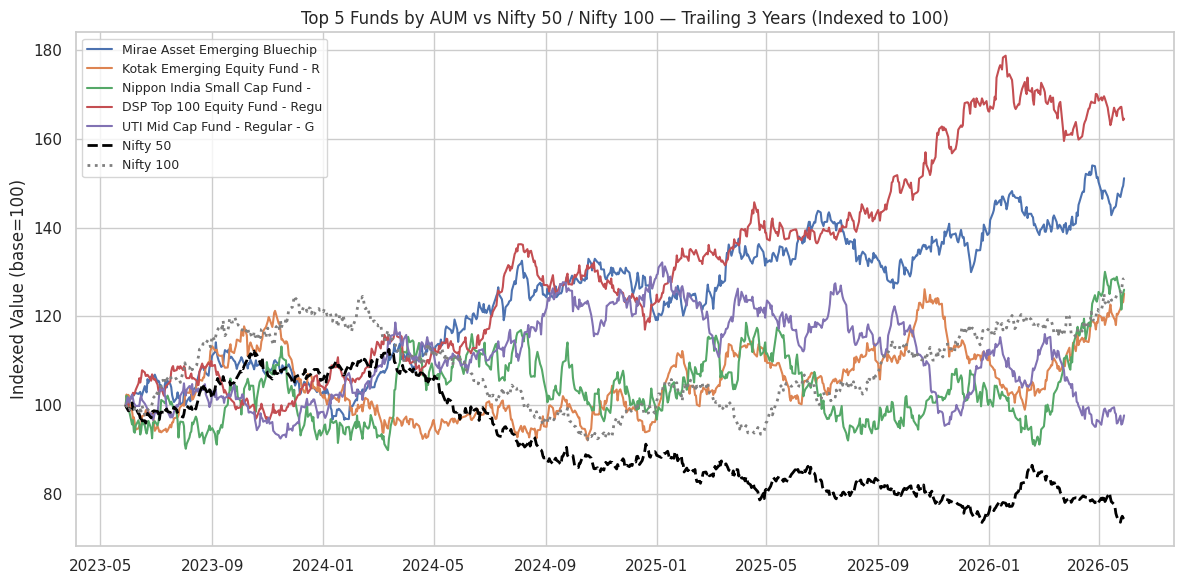

In [9]:
three_yr_start = as_of - pd.DateOffset(years=3)
top5 = perf_ref.nlargest(5, "aum_crore")["amfi_code"].tolist()

nifty50 = bench[bench["index_name"] == "NIFTY50"].sort_values("date")
nifty50_window = nifty50[nifty50["date"] >= three_yr_start].copy()
nifty50_window["indexed"] = nifty50_window["close_value"] / nifty50_window["close_value"].iloc[0] * 100

nifty100_window = nifty100.merge(bench[bench["index_name"] == "NIFTY100"][["date", "close_value"]], on="date")
nifty100_window = nifty100_window[nifty100_window["date"] >= three_yr_start].copy()
nifty100_window["indexed"] = nifty100_window["close_value"] / nifty100_window["close_value"].iloc[0] * 100

fig, ax = plt.subplots(figsize=(12, 6))
for code_ in top5:
    g = nav[(nav["amfi_code"] == code_) & (nav["date"] >= three_yr_start)].sort_values("date")
    indexed = g["nav"] / g["nav"].iloc[0] * 100
    name = fund_master.loc[fund_master["amfi_code"] == code_, "scheme_name"].iloc[0]
    ax.plot(g["date"], indexed, label=name[:30], linewidth=1.5)

ax.plot(nifty50_window["date"], nifty50_window["indexed"], label="Nifty 50", color="black", linestyle="--", linewidth=2)
ax.plot(nifty100_window["date"], nifty100_window["indexed"], label="Nifty 100", color="gray", linestyle=":", linewidth=2)

ax.set_title("Top 5 Funds by AUM vs Nifty 50 / Nifty 100 — Trailing 3 Years (Indexed to 100)")
ax.set_ylabel("Indexed Value (base=100)")
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
fig.savefig(CHART_DIR / "14_benchmark_comparison_top5.png", dpi=150, bbox_inches="tight")
plt.show()


In [10]:
# Tracking error vs Nifty 100 for the top 5
te_rows = []
for code_ in top5:
    g = nav[(nav["amfi_code"] == code_) & (nav["date"] >= three_yr_start)][["date", "daily_return"]]
    merged = g.merge(nifty100, on="date", how="inner").dropna()
    tracking_error = (merged["daily_return"] - merged["bench_return"]).std() * np.sqrt(TRADING_DAYS)
    name = fund_master.loc[fund_master["amfi_code"] == code_, "scheme_name"].iloc[0]
    te_rows.append({"scheme_name": name, "tracking_error_vs_nifty100": tracking_error})

te_df = pd.DataFrame(te_rows).sort_values("tracking_error_vs_nifty100")
te_df.style.format({"tracking_error_vs_nifty100": "{:.2%}"})


,scheme_name,tracking_error_vs_nifty100
3,DSP Top 100 Equity Fund - Regular - Growth,19.36%
0,Mirae Asset Emerging Bluechip Fund - Regular - Growth,20.55%
1,Kotak Emerging Equity Fund - Regular - Growth,22.03%
4,UTI Mid Cap Fund - Regular - Growth,22.33%
2,Nippon India Small Cap Fund - Regular - Growth,27.51%


**Reading tracking error:** a low tracking error means the fund moves
closely with Nifty 100 (common for large-cap funds); a high one means the
fund diverges a lot — could be active outperformance or active
underperformance, tracking error alone doesn't say which direction, only
that alpha (Task 5) tells you.